# Introduction

This notebook demonstrates how to use the `Agent` class to create a simple agent that interacts with an environment. We will create a random agent that takes random actions in the environment and observes the results.

In [1]:
import random
import numpy as np
import IPython.display

from bluebird_gymnasium.envs import BaseEnv, SectorIEnv

seed = 42

## 1. Instantiate a Scenario

Bluebird comes with several pre-built scenarios that you can use to test your agents. In this example, we will use the `SectorIEnv` scenario, which is a simple environment, instantiated with a single aircraft by default.

In [2]:
# TODO: can we do without having to set any config here
config = SectorIEnv.get_default_env_config()
config.view_config = {"type": "decentralized", "decentralized_params": {}}
env = SectorIEnv(config=config)
env.set_render_mode("human")

## 2. Create an Agent

An Agent has a `generate_action` method that takes in the current observation and info from the environment and returns an action. In this example, we will create a random agent that generates random actions.

In [3]:
class RandomAgent:
    def __init__(self):
        pass

    def generate_action(
        self,
        gym_env: BaseEnv,
        observation_dict: dict[str, np.ndarray],
        info_dict: dict[str, object]
    ) -> dict[str, int]:
        """Generate a gymnasium formatted action"""

        return {
            "AIR0": random.choice([0, 1, 2])
        }

Instantiate the agent.

In [4]:
agent = RandomAgent()

## 3. Run the Agent in the Environment

Now we write a loop in which the agent interacts with the environment. The loop continues until the episode is done, which is determined by the `done` flag returned by the environment. In each step, the agent generates an action based on the current observation and info, and then we take a step in the environment using that action. We also keep track of the rewards received at each step.

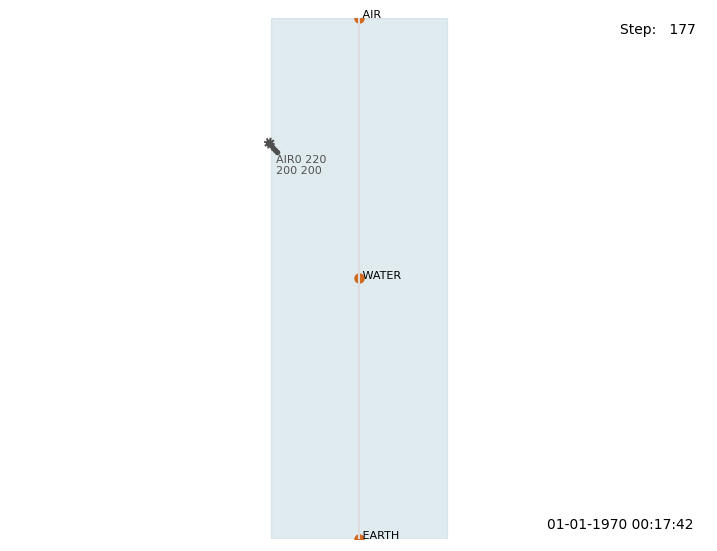

In [5]:
done = False
rewards = []
observation_dict, info_dict = env.reset(seed=seed)

while not done:
    action = agent.generate_action(env, observation_dict, info_dict)
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    rewards.append(reward_dict)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())pr
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)